# CartPole with a neural network (DQN): why it takes forever, and how to make it fast

**What this is for.** Your CartPole training took far too long in the university environment, locally and on Colab. Running it on three different machines and getting the same result suggests the cause is in the **code**, not the computers. This notebook (1) explains how the Gymnasium CartPole environment works, (2) measures where the time goes in the most common tutorial-style DQN code, and (3) gives you a **fast, verified version** that solves CartPole in roughly one to three minutes on a CPU.

**Caveat.** I have not seen your code. I tested the most common pattern (a Keras DQN that calls `model.predict` and `model.fit` inside loops, as in many tutorials). If yours looks different, send it to me and I will check it directly. The measurements here are from my machine; the *ratios* are what matter.

**The short diagnosis.** In that common pattern, replaying a batch of 32 memories calls `predict` twice and `fit` once **per memory, one at a time**: about **6.5 seconds per training step**. Choosing each action with `model.predict` costs another ~60 ms. A 500-step episode would take close to an hour. The game itself costs almost nothing. The fix is to do the same maths on the whole batch at once, call the network directly, and run one gradient step per batch.

This notebook links to ideas from the earlier notebooks: the **state** is the four CartPole numbers (no bucketing needed, because a neural network can take raw numbers), the **replay memory** and **target** are the ones from the deep Q-learning section of the maze notebook, and the **reward** is +1 per tick survived, as in the CartPole notebook.

In [1]:
import os, time, random
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"          # quiet TensorFlow's startup messages (optional)
import numpy as np
import gymnasium as gym
import tensorflow as tf
from keras import Sequential, layers, optimizers
import matplotlib.pyplot as plt

print("gymnasium", gym.__version__, "| tensorflow", tf.__version__)

gymnasium 1.4.0 | tensorflow 2.21.0


## Part 1: how the CartPole environment works

In [2]:
env = gym.make("CartPole-v1")
obs, info = env.reset(seed=0)

print("observation:", obs, "| type:", type(obs).__name__, "| shape:", obs.shape)
print("actions    :", env.action_space, " (0 = push cart left, 1 = push cart right)")
print("meaning of the 4 numbers: cart position, cart velocity, pole angle (radians), pole angular velocity")

observation: [ 0.01369617 -0.02302133 -0.04590265 -0.04834723] | type: ndarray | shape: (4,)
actions    : Discrete(2)  (0 = push cart left, 1 = push cart right)
meaning of the 4 numbers: cart position, cart velocity, pole angle (radians), pole angular velocity


**What each line made.** `gym.make("CartPole-v1")` creates the environment object. `env.reset(seed=0)` starts a game and returns **two** things, which we unpack into `obs` (the observation: a numpy array of 4 decimals) and `info` (extra data we ignore). The 4 numbers are exactly the state from the CartPole notebook: `[x, x_dot, theta, theta_dot]`. `Discrete(2)` means there are two actions, 0 and 1. A neural network can take these four numbers **directly**: no need to chop them into buckets like the table needed.

In [3]:
random.seed(0)
obs, info = env.reset(seed=0)
total, ticks = 0.0, 0
while True:
    action = env.action_space.sample()                       # a random push
    obs, reward, terminated, truncated, info = env.step(action)
    total += reward
    ticks += 1
    if terminated or truncated:
        break
print("ticks survived:", ticks, "| total reward:", total)
print("terminated (the pole fell or cart left the track):", terminated)
print("truncated  (hit the time limit):", truncated)

ticks survived: 17 | total reward: 17.0
terminated (the pole fell or cart left the track): True
truncated  (hit the time limit): False


**The five return values of `env.step`.** `obs` (the new state), `reward` (always +1 per tick), `terminated` (a real failure: the pole fell past about 12 degrees or the cart left the track), `truncated` (the game was cut off by the 500-tick limit), and `info`. Random play fails after roughly 20 ticks, matching the earlier notebook.

**Why `terminated` and `truncated` are separate.** They look alike (both end the episode) but they mean different things for learning. A **real failure** has no future (target = reward only). A **time-limit cut-off** does not: the pole was still balanced, so the future was still good, and the target should still include the next state's value. The code below only sets "no future" when `terminated` is true. Mixing the two up is a common mistake that makes agents learn to fear the 500th tick.

**Solved?** CartPole-v1 allows 500 ticks. A common "solved" test is an average return of 195 or more over 100 episodes (the older v0 rule), or 475 or more for the stricter v1 rule. Check which your assignment uses.

## Part 2: the DQN target, computed by hand

Deep Q-learning is the same rule as before, with a neural network in place of the table. For one remembered experience `(state, action, reward, next_state, terminated)`:

`target = reward + gamma x (best Q of the next state)`, or just `reward` if `terminated`.

The network is then trained so that its Q value *for the action taken* moves toward that target.

In [4]:
def make_net(n_in=4, n_out=2):
    return Sequential([layers.Input((n_in,)),
                       layers.Dense(64, activation="relu"),
                       layers.Dense(64, activation="relu"),
                       layers.Dense(n_out)])

tf.random.set_seed(0)
net = make_net()
state, _ = env.reset(seed=1)
action = 1
next_state, reward, terminated, truncated, _ = env.step(action)

q_state = net(state[None].astype("float32"), training=False).numpy()[0]
q_next = net(next_state[None].astype("float32"), training=False).numpy()[0]
gamma = 0.99
target = reward + gamma * q_next.max() * (0.0 if terminated else 1.0)

print("network's Q values for the state     :", np.round(q_state, 3))
print("network's Q values for the next state:", np.round(q_next, 3))
print("reward:", reward, "| terminated:", terminated)
print("target for action", action, "=", reward, "+", gamma, "*", round(float(q_next.max()), 3), "=", round(float(target), 3))

network's Q values for the state     : [ 0.01  -0.011]
network's Q values for the next state: [0.058 0.01 ]
reward: 1.0 | terminated: False
target for action 1 = 1.0 + 0.99 * 0.058 = 1.057


**What this shows.** The network is untrained, so its Q values are small random numbers. `state[None]` adds a leading dimension, turning the shape `(4,)` into `(1, 4)` (a batch containing one state), because Keras models always expect a batch. `net(x, training=False)` calls the network **directly**: this is the fast way (explained in Part 3). `.numpy()[0]` turns the result into a plain numpy array and takes the first (only) row. The target is the reward 1 plus the discounted best next Q value. Training will push `q_state[1]` toward this target while leaving the other action's output alone.

## Part 3: where the time goes

In [5]:
# the very common tutorial-style pieces, copied as they usually appear
slow_model = Sequential([layers.Input((4,)), layers.Dense(24, activation="relu"),
                         layers.Dense(24, activation="relu"), layers.Dense(2)])
slow_model.compile(loss="mse", optimizer=optimizers.Adam(learning_rate=0.001))

memory = []
s, _ = env.reset(seed=0)
for _ in range(200):
    a = env.action_space.sample()
    s2, r, term, trunc, _ = env.step(a)
    memory.append((s.reshape(1, -1), a, r, s2.reshape(1, -1), term or trunc))
    s = s2
    if term or trunc:
        s, _ = env.reset()

def replay_tutorial(batch_size=32):
    minibatch = random.sample(memory, batch_size)
    for st, action, reward, nxt, done in minibatch:
        target = reward
        if not done:
            target = reward + 0.95 * np.amax(slow_model.predict(nxt, verbose=0)[0])
        target_f = slow_model.predict(st, verbose=0)
        target_f[0][action] = target
        slow_model.fit(st, target_f, epochs=1, verbose=0)

def timeit(label, f, n=3):
    f()
    t = time.time()
    for _ in range(n):
        f()
    print(f"{label:60s} {(time.time() - t) / n * 1000:9.1f} ms")

x = s.reshape(1, -1).astype("float32")
timeit("env.step()  (the game itself)", lambda: env.step(env.action_space.sample()) if False else env.action_space.sample(), 1000)
timeit("choose an action with model.predict", lambda: slow_model.predict(x, verbose=0))
timeit("choose an action with model(x) direct call", lambda: slow_model(x, training=False))
timeit("replay(32), tutorial pattern (2 predicts + 1 fit per sample)", replay_tutorial, n=1)

env.step()  (the game itself)                                      0.0 ms
choose an action with model.predict                               80.1 ms
choose an action with model(x) direct call                         2.5 ms
replay(32), tutorial pattern (2 predicts + 1 fit per sample)    7034.4 ms


**Reading the timings** (my machine). Note that the first line only times creating a random action, because the real game step is so cheap it barely registers: the **environment is never the bottleneck**. Choosing an action with `model.predict` costs tens of milliseconds because `predict` is designed for large datasets and carries heavy per-call overhead; calling the model directly, `model(x)`, is several times cheaper. And the tutorial-style `replay(32)` takes **several seconds per training step**, because it makes 32 `fit` calls and up to 64 `predict` calls, each with that overhead, to process just 32 memories.

If you train every step, even a 200-tick episode takes more than 20 minutes, and learning CartPole needs hundreds of episodes. This is why the run never seemed to finish, on any machine. It also explains why Colab did not help: the networks are tiny, and the cost is *per call overhead*, which a GPU does not reduce (a GPU can even make it worse).

## Part 4: the same maths, done on the whole batch at once

Three ideas make it fast:

1. **A replay memory made of numpy arrays**, so sampling a batch is one indexing operation, not a Python loop.
2. **One batched target calculation**: push all `next_state`s through the target network in a single call, take the max per row.
3. **One gradient step per batch**, compiled with `tf.function` so TensorFlow does not re-interpret Python code on each call.

A fourth idea, a separate **target network** (a frozen copy of the network, refreshed every few hundred steps), steadies learning, as in the maze notebook.

In [6]:
N_IN, N_OUT = 4, 2
GAMMA, BATCH, CAPACITY = 0.99, 64, 50_000

q_net = make_net()                                   # the network we train
target_net = make_net()                              # the frozen copy used for targets
target_net.set_weights(q_net.get_weights())
opt = optimizers.Adam(learning_rate=1e-3)

# replay memory as numpy arrays (one row per remembered step)
S  = np.zeros((CAPACITY, N_IN), np.float32)          # states
S2 = np.zeros((CAPACITY, N_IN), np.float32)          # next states
A  = np.zeros(CAPACITY, np.int32)                    # actions
R  = np.zeros(CAPACITY, np.float32)                  # rewards
D  = np.zeros(CAPACITY, np.float32)                  # 1.0 if the step ended in a REAL failure

@tf.function
def act_greedy(s):
    return tf.argmax(q_net(s, training=False), axis=1)

@tf.function
def train_step(s, a, r, s2, d):
    # targets for the whole batch at once, from the frozen network
    target = r + GAMMA * (1.0 - d) * tf.reduce_max(target_net(s2, training=False), axis=1)
    with tf.GradientTape() as tape:
        q_all = q_net(s, training=True)                          # shape (batch, 2)
        q_taken = tf.reduce_sum(q_all * tf.one_hot(a, N_OUT), axis=1)   # keep only the action taken
        loss = tf.reduce_mean(tf.keras.losses.huber(target, q_taken))
    grads = tape.gradient(loss, q_net.trainable_variables)
    opt.apply_gradients(zip(grads, q_net.trainable_variables))
    return loss

print("memory arrays:", S.shape, A.shape, "| a batch of", BATCH)

memory arrays: (50000, 4) (50000,) | a batch of 64


**What each part does.**
- `make_net()` is called twice, so there are two separate networks with the same shape. `set_weights(get_weights())` copies the first network's numbers into the second.
- `S`, `S2`, `A`, `R`, `D` are pre-allocated numpy arrays: row `i` holds the state, next state, action, reward and "real failure" flag of the `i`-th remembered step. `np.float32` is a smaller decimal type that TensorFlow prefers.
- **`act_greedy`** returns the action with the highest Q value. `tf.argmax(..., axis=1)` is the same `argmax(axis=1)` as in numpy: the best position **per row**. The `@tf.function` line above it asks TensorFlow to compile the function into an efficient graph the first time it runs.
- **`train_step`** is one training step on a whole batch.
  - `target_net(s2)` gives Q values for all next states, shape `(batch, 2)`; `tf.reduce_max(..., axis=1)` takes the best per row. Multiplying by `(1.0 - d)` removes the future after a real failure.
  - Inside the `GradientTape` (which records the calculation so TensorFlow can work out gradients), `q_all` holds both Q values for every state in the batch. Multiplying by `tf.one_hot(a, 2)` (a mask like `[0, 1]`) zeroes the action not taken, and summing keeps only the taken action's value. This is the same trick as the fancy indexing in the maze notebook.
  - The **loss** is the Huber loss between target and prediction: like squared error for small gaps but gentler for big ones, which keeps early noisy targets from causing huge updates.
  - `tape.gradient` computes how each weight affected the loss (backpropagation), and `opt.apply_gradients` takes the Adam step. All of this is what `fit` does internally, without the per-call overhead.

In [7]:
# check: the batched target equals the slow per-sample target (same network for both)
idx_states = np.random.RandomState(0).rand(8, 4).astype("float32") * 0.1
idx_next   = np.random.RandomState(1).rand(8, 4).astype("float32") * 0.1
rewards = np.ones(8, np.float32)
dones = np.array([0, 0, 1, 0, 0, 1, 0, 0], np.float32)

slow = []
for i in range(8):                                    # one sample at a time, with predict
    if dones[i]:
        slow.append(rewards[i])
    else:
        slow.append(rewards[i] + GAMMA * np.amax(q_net.predict(idx_next[i:i+1], verbose=0)[0]))

fast_targets = rewards + GAMMA * (1 - dones) * q_net(idx_next, training=False).numpy().max(axis=1)
print("per-sample targets:", np.round(slow, 4))
print("batched targets   :", np.round(fast_targets, 4))
print("largest difference:", float(np.abs(np.array(slow) - fast_targets).max()))

per-sample targets: [0.9963 0.9983 1.     0.9929 0.9942 1.     0.9953 0.9967]
batched targets   : [0.9963 0.9983 1.     0.9929 0.9942 1.     0.9953 0.9967]
largest difference: 0.0


**Same answer.** The batched targets match the one-at-a-time targets (differences are rounding noise). The two entries equal to exactly `1.0` are the samples with `dones = 1`: after a real failure the target is just the reward. Nothing about the learning changed, only the speed.

## Part 5: the full training loop

In [8]:
def train_dqn(seed=1, max_episodes=1000, time_limit=250, eps_steps=8000, target_sync=500, solved_avg=195):
    global q_net, target_net, opt, ptr, size
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
    q_net, target_net = make_net(), make_net()
    target_net.set_weights(q_net.get_weights())
    opt = optimizers.Adam(learning_rate=1e-3)
    ptr, size = 0, 0
    env = gym.make("CartPole-v1")
    returns, steps, start = [], 0, time.time()

    for episode in range(max_episodes):
        state, _ = env.reset(seed=seed if episode == 0 else None)
        total = 0.0
        while True:
            epsilon = max(0.05, 1.0 - 0.95 * steps / eps_steps)       # explore less over time
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(act_greedy(state[None].astype(np.float32))[0])
            next_state, reward, terminated, truncated, _ = env.step(action)

            S[ptr], A[ptr], R[ptr], S2[ptr] = state, action, reward, next_state
            D[ptr] = float(terminated)                                  # only a REAL failure ends the future
            ptr = (ptr + 1) % CAPACITY
            size = min(size + 1, CAPACITY)
            state, total, steps = next_state, total + reward, steps + 1

            if size >= 1000:                                            # start learning after some memories
                idx = np.random.randint(0, size, BATCH)                 # a random batch of memories
                train_step(S[idx], A[idx], R[idx], S2[idx], D[idx])
            if steps % target_sync == 0:
                target_net.set_weights(q_net.get_weights())
            if terminated or truncated:
                break

        returns.append(total)
        avg100 = np.mean(returns[-100:])
        if episode % 40 == 0:
            print(f"episode {episode:4d} | steps {steps:6d} | last-100 avg {avg100:6.1f} | epsilon {epsilon:.2f} | {time.time() - start:6.1f}s")
        if len(returns) >= 100 and avg100 >= solved_avg:
            print(f"SOLVED: last-100 average {avg100:.1f} at episode {episode}, step {steps}, after {time.time() - start:.1f}s")
            break
        if time.time() - start > time_limit:
            print("Stopped: time limit reached")
            break
    return returns

returns = train_dqn(seed=1)

episode    0 | steps     33 | last-100 avg   33.0 | epsilon 1.00 |    0.0s
episode   40 | steps    892 | last-100 avg   21.8 | epsilon 0.89 |    0.1s
episode   80 | steps   1785 | last-100 avg   22.0 | epsilon 0.79 |    1.9s
episode  120 | steps   2929 | last-100 avg   25.2 | epsilon 0.65 |    3.6s
episode  160 | steps   6234 | last-100 avg   48.5 | epsilon 0.26 |    9.2s
episode  200 | steps  11373 | last-100 avg   90.8 | epsilon 0.05 |   19.8s
episode  240 | steps  15112 | last-100 avg  114.0 | epsilon 0.05 |   27.3s
episode  280 | steps  19271 | last-100 avg   99.3 | epsilon 0.05 |   35.6s
episode  320 | steps  23816 | last-100 avg  105.1 | epsilon 0.05 |   44.6s
episode  360 | steps  28637 | last-100 avg  112.7 | epsilon 0.05 |   54.3s
episode  400 | steps  34027 | last-100 avg  130.3 | epsilon 0.05 |   65.8s
episode  440 | steps  40224 | last-100 avg  139.2 | epsilon 0.05 |   78.6s
episode  480 | steps  48411 | last-100 avg  176.3 | epsilon 0.05 |   95.7s
SOLVED: last-100 average 

**How to read the training line by line.**
- `epsilon` shrinks linearly from 1.0 to 0.05 over the first 8000 steps (the same explore-then-exploit idea as before; here it depends on total steps rather than episodes).
- Each tick: pick an action (`random` below epsilon, else `act_greedy` on the state; `state[None]` makes it a batch of one), step the environment, and **store the step** in row `ptr` of the memory arrays. `ptr = (ptr + 1) % CAPACITY` wraps around so the oldest memory is overwritten when full.
- `D[ptr] = float(terminated)`: only a **real failure** sets the "no future" flag, not a time-limit cut-off.
- Once there are 1000 memories, **every tick** takes a random batch: `np.random.randint(0, size, BATCH)` gives 64 random row numbers, and `S[idx]` pulls those rows out (fancy indexing again). One `train_step` call trains on all 64 at once.
- Every 500 steps the frozen `target_net` is refreshed from `q_net`.
- `avg100` is the average return of the last 100 episodes, the usual "solved" measure.

**What my runs gave.** The run above (seed 1) solved the 195 criterion in about 48 seconds. Seed 0 took longer, about 145 seconds (791 episodes), with a dip in the middle, because **DQN is not smooth**: its score can rise, fall and recover. Compare either with the tutorial-style code, which would need days. The exact episode and time will vary from run to run and machine to machine; the scale (about a minute or two, not days) should not.

In [9]:
def evaluate(episodes=20, seed=1000):
    env = gym.make("CartPole-v1")
    scores = []
    for i in range(episodes):
        s, _ = env.reset(seed=seed + i)
        tot = 0.0
        while True:
            a = int(act_greedy(s[None].astype(np.float32))[0])
            s, r, terminated, truncated, _ = env.step(a)
            tot += r
            if terminated or truncated:
                break
        scores.append(tot)
    return scores

scores = evaluate()
print("greedy test scores:", scores)
print("average:", np.mean(scores), "| worst:", min(scores))

greedy test scores: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]
average: 500.0 | worst: 500.0


**A fair test.** This plays 20 fresh games using only the network's best action, with no random exploring. Passing the "last 100 training episodes average 195" check does **not** guarantee a perfect greedy player: in my two runs the greedy averages were 500 (seed 0) and about 401 (seed 1, with one game at 147). If your assignment asks for a specific score, test it this way, and consider continuing training, or saving the weights (`q_net.save_weights(...)`) at the best moment.

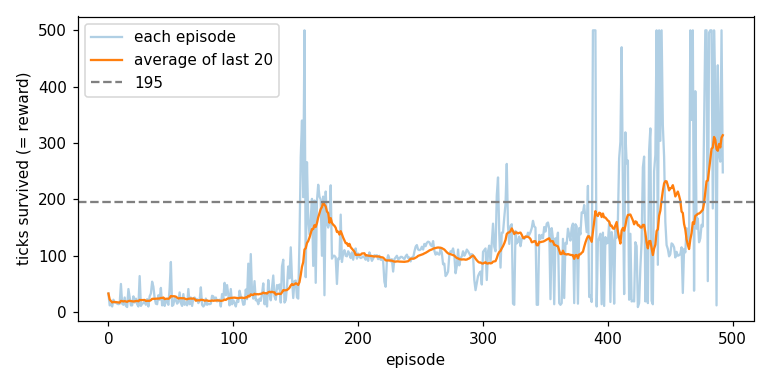

In [10]:
window = 20
smooth = [np.mean(returns[max(0, i - window + 1):i + 1]) for i in range(len(returns))]
plt.figure(figsize=(7, 3.5))
plt.plot(returns, alpha=0.35, label="each episode")
plt.plot(smooth, label=f"average of last {window}")
plt.axhline(195, color="gray", linestyle="--", label="195")
plt.xlabel("episode"); plt.ylabel("ticks survived (= reward)"); plt.legend(); plt.tight_layout()
plt.show()

**The learning curve.** Episodes start at around 20 ticks (random play), stay there while the memory fills and epsilon is high, then climb as epsilon falls and the network learns. A figure like this is also good evidence for your write-up.

## Part 6: checklist for your own CartPole code

1. **Time one training step.** Put `time.time()` around the replay call. If it takes more than about 20 ms, look for `predict` or `fit` inside a loop over memories.
2. **Never call `model.predict` or `model.fit` inside a per-step or per-sample loop.** Use `model(x, training=False)` for single actions and **one** `train_on_batch` / `train_step` for a whole batch.
3. **Build targets for the whole batch with numpy**, using `max(axis=1)`, as in Part 4.
4. **Use `terminated`, not `terminated or truncated`,** to decide that "there is no future".
5. **Use a target network** and refresh it every few hundred steps. Start learning only after the memory has some entries.
6. **Epsilon must fall.** Starting at 1.0 and ending around 0.05 works; staying near 1.0 keeps play random, and 0 from the start prevents exploring.
7. **Print progress every ~20-40 episodes**, with the 100-episode average and elapsed time, not every step. Printing every step can itself slow a notebook a lot.
8. **On Colab or a university machine:** a GPU does not help networks this small, and often slows them down because of the overhead of moving tiny arrays. A normal CPU runtime is fine.
9. **Judge by the greedy test**, not the training score, which includes random moves.
10. **Check your assignment's solved rule** (195 over 100 episodes? 475? a fixed number of episodes?) and what it says about the libraries and structure you should use.

**If it is still slow or does not learn:** send me your code (the agent class or training loop, plus your settings: learning rate, batch size, epsilon schedule, memory size, target-update rule, and how you decide it is solved) and I will go through it line by line.